# Fallout Plots

In [3]:
import xarray as xr
import matplotlib.pyplot as plt

In [12]:
# read in data
path = "~/Documents/Univie_Meteo/ClimateLab/project_climlab/output_files/"

ds_jan_plvl = xr.open_dataset(path + "test_3d_jan_plvl.nc")
ds_jan = xr.open_dataset(path + "test_3d_jan_remap.nc")
ds_feb = xr.open_dataset(path + "test_3d_feb_remap.nc")
ds_mar = xr.open_dataset(path + "test_3d_mar_remap.nc")
ds_apr = xr.open_dataset(path + "test_3d_apr_remap.nc")
ds_may = xr.open_dataset(path + "test_3d_may_remap.nc")

ds_jan

<xarray.Dataset> Size: 146MB
Dimensions:      (height: 47, bnds: 2, lat: 180, lon: 360, time: 1)
Coordinates:
  * height       (height) float64 376B 1.0 2.0 3.0 4.0 ... 44.0 45.0 46.0 47.0
  * lat          (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon          (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * time         (time) float64 8B 1.979e+07
Dimensions without coordinates: bnds
Data variables: (12/14)
    height_bnds  (height, bnds) float64 752B ...
    zg           (height, lat, lon) float32 12MB ...
    ps           (time, lat, lon) float32 259kB ...
    pfull        (time, height, lat, lon) float32 12MB ...
    rho          (time, height, lat, lon) float32 12MB ...
    ta           (time, height, lat, lon) float32 12MB ...
    ...           ...
    wap          (time, height, lat, lon) float32 12MB ...
    hus          (time, height, lat, lon) float32 12MB ...
    clw          (time, height, lat, lon) float32 12MB ...
    cli          (time, height, lat, lon) float32 12MB ...
    hur          (time, height, lat, lon) float32 12MB ...
    cl           (time, height, lat, lon) float32 12MB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    uuidOfVGrid:  0a1df915-12fb-d8bd-ed0c-cb104a832900
    source:       Unknown@Unknown
    institution:  Max Planck Institute for Meteorology/Deutscher Wetterdienst
    title:        ICON simulation
    history:      Sun Apr 26 17:36:59 2026: cdo remapcon,r360x180 testyear_at...
    references:   see MPIM/DWD publications
    comment:      None ICON17 (icon17) on n4907-070 (Linux 4.18.0-477.10.1.el...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

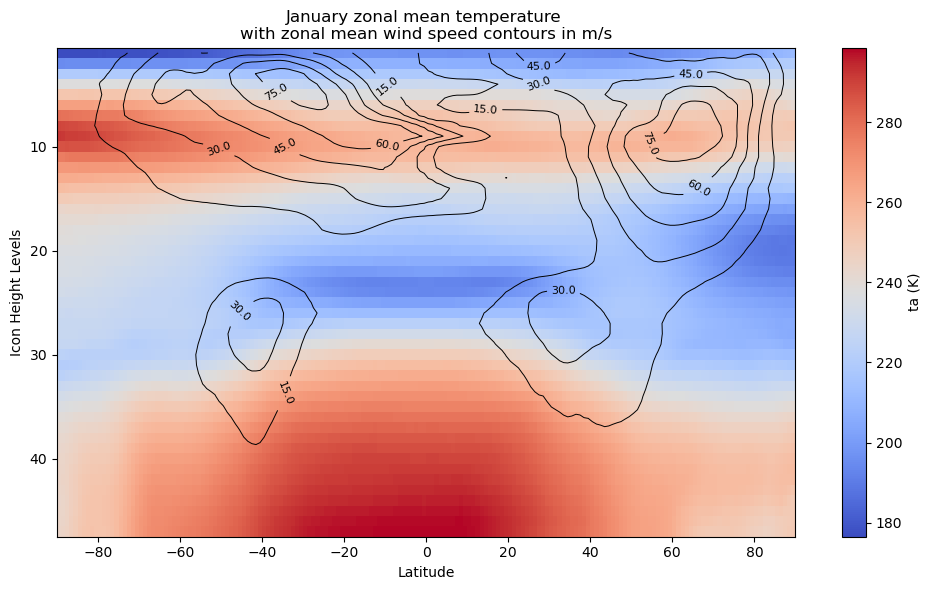

In [15]:
# zonal mean temperature for January from the ICON remapped file

# temperature zonal mean
ta = ds_jan["ta"]
temp_zonal_mean = ta.mean(dim="time").mean(dim="lon").transpose("height", "lat")

# zonal mean wind speed from ua and va
u_zonal_mean = ds_jan["ua"].mean(dim="time").mean(dim="lon").transpose("height", "lat")
v_zonal_mean = ds_jan["va"].mean(dim="time").mean(dim="lon").transpose("height", "lat")
wind_zonal_mean = (u_zonal_mean ** 2 + v_zonal_mean ** 2) ** 0.5

fig, ax = plt.subplots(figsize=(10, 6))
mesh = ax.pcolormesh(
    temp_zonal_mean["lat"],
    temp_zonal_mean["height"],
    temp_zonal_mean,
    shading="auto",
    cmap="coolwarm",
)

# overlay wind speed as contour lines
contours = ax.contour(
    wind_zonal_mean["lat"],
    wind_zonal_mean["height"],
    wind_zonal_mean,
    colors="black",
    linewidths=0.7,
)
ax.clabel(contours, inline=True, fontsize=8, fmt="%.1f")

ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Icon Height Levels")
ax.set_title("January zonal mean temperature \nwith zonal mean wind speed contours in m/s")
fig.colorbar(mesh, ax=ax, label="ta (K)")
fig.tight_layout()
plt.show()

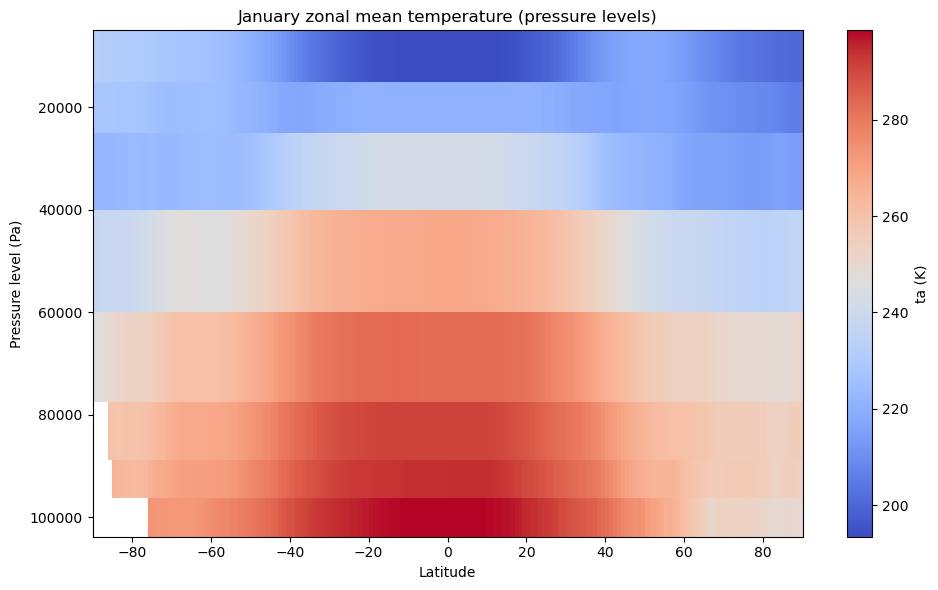

In [10]:
# zonal mean temperature for January from the ICON pressure-level file

da = ds_jan_plvl["ta"]
zonal_mean = da.mean(dim="time").mean(dim="lon").transpose("plev", "lat")

fig, ax = plt.subplots(figsize=(10, 6))
mesh = ax.pcolormesh(
    zonal_mean["lat"],
    zonal_mean["plev"],
    zonal_mean,
    shading="auto",
    cmap="coolwarm",
)
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Pressure level (Pa)")
ax.set_title("January zonal mean temperature (pressure levels)")
fig.colorbar(mesh, ax=ax, label="ta (K)")
fig.tight_layout()
plt.show()

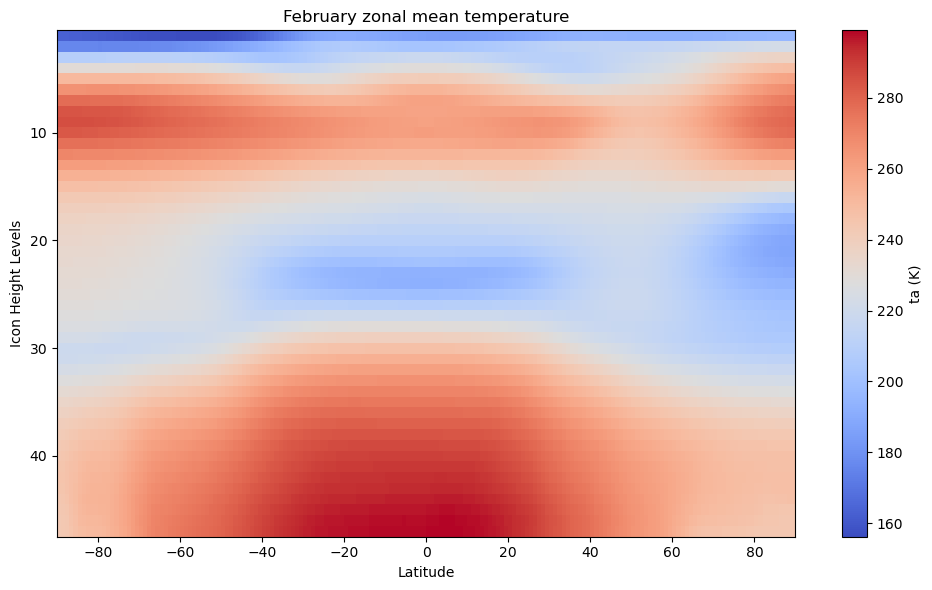

In [ ]:
# zonal mean temperature for February from the ICON remapped file

da = ds_feb["ta"]
zonal_mean = da.mean(dim="time").mean(dim="lon").transpose("height", "lat")

fig, ax = plt.subplots(figsize=(10, 6))
mesh = ax.pcolormesh(
    zonal_mean["lat"],
    zonal_mean["height"],
    zonal_mean,
    shading="auto",
    cmap="coolwarm",
)
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Icon Height Levels")
ax.set_title("February zonal mean temperature")
fig.colorbar(mesh, ax=ax, label="ta (K)")
fig.tight_layout()
plt.show()

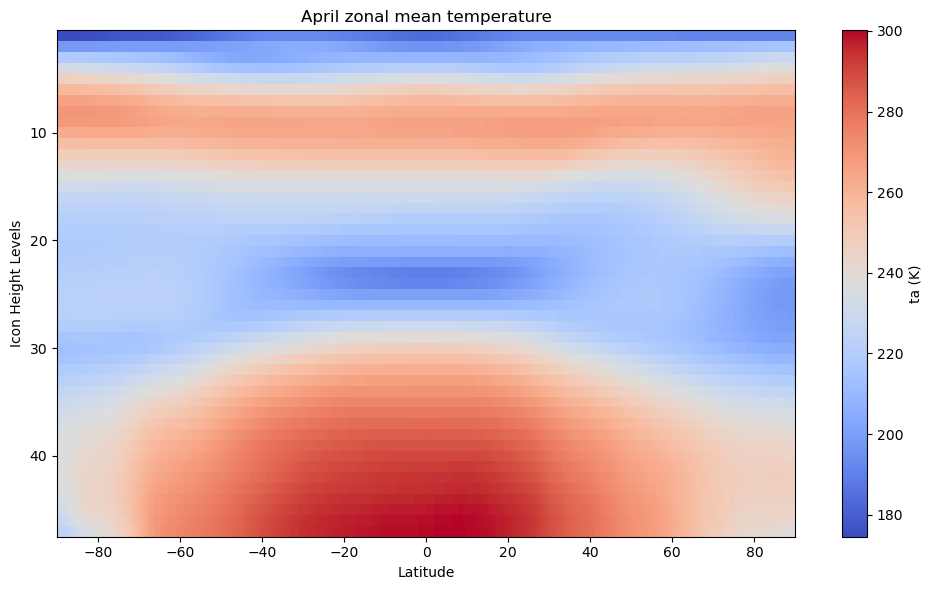

In [ ]:
# zonal mean temperature for April from the ICON remapped file

da = ds_apr["ta"]
zonal_mean = da.mean(dim="time").mean(dim="lon").transpose("height", "lat")

fig, ax = plt.subplots(figsize=(10, 6))
mesh = ax.pcolormesh(
    zonal_mean["lat"],
    zonal_mean["height"],
    zonal_mean,
    shading="auto",
    cmap="coolwarm",
)
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Icon Height Levels")
ax.set_title("April zonal mean temperature")
fig.colorbar(mesh, ax=ax, label="ta (K)")
fig.tight_layout()
plt.show()